# Desafío 2 — Word Embeddings con Word2Vec
**Materia:** Procesamiento del Lenguaje Natural  
**Especialización en Inteligencia Artificial — CEIA-FIUBA**

**Corpus:** *El problema de los tres cuerpos* — Liu Cixin

---
### Estructura del notebook
1. Imports y descarga de recursos NLTK
2. Carga del corpus desde archivo de texto
3. Preprocesamiento (tokenización, limpieza, stopwords)
4. Entrenamiento del modelo Word2Vec con Gensim
5. Exploración de similitudes (`most_similar`, analogías)
6. Visualización con t-SNE
7. Análisis e interpretación de clusters

## 2. Imports y descarga de recursos NLTK

In [68]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from collections import Counter


import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

from gensim.models import Word2Vec
from sklearn.manifold import TSNE

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print('Imports OK')

Imports OK


[nltk_data] Downloading package punkt to /home/facundo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/facundo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/facundo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 3. Carga del corpus

El texto fue extraído del epub y guardado en `corpus_tres_cuerpos.txt`.

In [ ]:
RUTA_CORPUS = 'corpus_tres_cuerpos.txt'
IDIOMA      = 'spanish'

with open(RUTA_CORPUS, encoding="utf-8") as f:
    texto_crudo = f.read()

print(f'Caracteres cargados : {len(texto_crudo):,}')
print('\n--- Muestra (chars 500-1200) ---')
print(texto_crudo[500:1200])

In [70]:
# Inspección de las primeras líneas para detectar ruido (índices, metadatos, etc.)
lineas = [l.strip() for l in texto_crudo.split('\n') if l.strip()]
print(f'Total de líneas no vacías: {len(lineas):,}\n')
for i, linea in enumerate(lineas[:50]):
    print(f'{i:3d}: {linea}')

Total de líneas no vacías: 4,023

  0: ELENCO DE PERSONAJES
  1: 1
  2: La familia Ye
  3: Ye Zhetai:
  4: Profesor de Física de la Universidad de Tsinghua de Pekín.
  5: Shao Lin:
  6: Esposa de Ye Zhetai y, al igual que aquel, profesora de Física en la misma universidad.
  7: Ye Wenjie:
  8: Astrofísica. Primogénita de Ye Zhetai y Shao Lin.
  9: Base Costa Roja
 10: Lei Zhicheng:
 11: Comisario político de la base.
 12: Yang Weining:
 13: Ingeniero jefe de la base. Antiguo alumno de Ye Zhetai.
 14: El presente
 15: Yang Dong:
 16: Teórica de cuerdas. Hija de Yang Weining y Ye Wenjie.
 17: Ding Yi:
 18: Físico teórico. Novio de Yang Dong.
 19: Wang Miao:
 20: Investigador en nanomateriales. Tiene un hijo, Dou Dou, de su matrimonio con Li Yao.
 21: Shi Qiang:
 22: Comisario de policía apodado «Da Shi». Tan soez en sus maneras como eficaz en su trabajo. Fumador em­pedernido.
 23: Chang Weisi:
 24: General del Ejército Popular de Liberación de la República Popular de China.
 25: Shen Yuf

In [ ]:
def limpiar_texto(texto, min_longitud_linea=10):
    """
    Limpieza básica del texto extraído del epub.
    - Elimina líneas muy cortas (numeración, títulos de 1-2 palabras)
    - Normaliza espacios
    """
    lineas = texto.split('\n')
    lineas_utiles = [
        l.strip() for l in lineas
        if len(l.strip()) >= min_longitud_linea
    ]
    texto_unido = ' '.join(lineas_utiles)
    texto_unido = re.sub(r'\s+', ' ', texto_unido)
    return texto_unido.strip()

texto_limpio = limpiar_texto(texto_crudo)

print(f'Caracteres después de limpiar: {len(texto_limpio):,}')
print('\n--- Muestra del texto limpio ---')
print(texto_limpio[:600])

## 4. Preprocesamiento

El corpus para Word2Vec debe ser una **lista de listas de tokens**: cada sublista es una oración o párrafo.

Pipeline: tokenización por oraciones → tokenización por palabras → lowercase → eliminación de puntuación → filtro de stopwords.

In [72]:
STOPWORDS = set(stopwords.words(IDIOMA))

def preprocesar_oracion(texto, idioma=IDIOMA):
    """
    Devuelve lista de tokens limpios para una oración.
    Conserva letras (incluye acentos y ñ para español).
    """
    texto = texto.lower()
    texto = re.sub(r'[^\w\sáéíóúüñ]', '', texto)   # elimina puntuación
    tokens = word_tokenize(texto, language=idioma)
    tokens = [
        t for t in tokens
        if t not in STOPWORDS
        and len(t) > 2             # descarta tokens muy cortos
        and not t.isdigit()        # descarta números puros
    ]
    return tokens

# Dividir el texto en oraciones
oraciones = sent_tokenize(texto_limpio, language=IDIOMA)
print(f'Oraciones detectadas: {len(oraciones):,}')
print(f'Ejemplo oración cruda: {oraciones[5]}')

Oraciones detectadas: 7,432
Ejemplo oración cruda: Antiguo alumno de Ye Zhetai.


In [73]:
# Preprocesar todas las oraciones
corpus = [preprocesar_oracion(o) for o in oraciones]

# Filtrar oraciones que quedaron con menos de 3 tokens
corpus = [tokens for tokens in corpus if len(tokens) >= 3]

# Estadísticas del corpus
todos_los_tokens = [t for oracion in corpus for t in oracion]
vocabulario = set(todos_los_tokens)

print(f'Oraciones en el corpus   : {len(corpus):,}')
print(f'Tokens totales           : {len(todos_los_tokens):,}')
print(f'Vocabulario único        : {len(vocabulario):,}')
print(f'\nEjemplo de oración procesada:\n  {corpus[5]}')

# Palabras más frecuentes (útil para elegir qué consultar después)
freq = Counter(todos_los_tokens)
print(f'\nTop 20 palabras más frecuentes:')
for palabra, count in freq.most_common(20):
    print(f'  {palabra:<20} {count}')

Oraciones en el corpus   : 6,627
Tokens totales           : 59,567
Vocabulario único        : 13,531

Ejemplo de oración procesada:
  ['hija', 'yang', 'weining', 'wenjie']

Top 20 palabras más frecuentes:
  wang                 427
  dos                  255
  dijo                 227
  tan                  221
  sol                  209
  gran                 206
  tres                 206
  mundo                202
  solo                 201
  aquel                192
  vez                  192
  ser                  178
  tiempo               176
  luz                  173
  shi                  151
  tierra               149
  aquella              139
  wenjie               138
  ahora                137
  roja                 135


## 5. Entrenamiento de Word2Vec con Gensim

Usamos **Skip-gram** (`sg=1`) porque el corpus, aunque es una novela completa, tiene vocabulario técnico y nombres propios que son relativamente infrecuentes. Skip-gram funciona mejor en esos casos.

| Parámetro | Valor elegido | Justificación |
|-----------|--------------|---------------|
| `vector_size` | 50 | Corpus pequeño (~60k tokens); ≈ √vocab_modelo evita underfitting por falta de datos |
| `window` | 5 | Captura contexto local (relaciones semánticas directas) |
| `min_count` | 3 | Descarta palabras que aparecen menos de 3 veces |
| `negative` | 10 | Más muestras negativas para corpus de tamaño moderado |
| `workers` | 1 | Necesario para reproducibilidad con `seed` fijo; con >1 worker el orden de actualizaciones es no determinista |
| `sg` | 1 | Skip-gram, mejor para vocabulario rico y términos raros |
| `epochs` | 30 | Más épocas para compensar el corpus pequeño |

In [ ]:
model = Word2Vec(
    sentences=corpus,
    vector_size=50,
    window=5,
    min_count=3,
    negative=10,
    sg=1,           # 1 = Skip-gram, 0 = CBOW
    epochs=30,
    workers=1,
    seed=42
)

model.save('word2vec_tres_cuerpos.model')

print(f'Vocabulario del modelo : {len(model.wv):,} palabras')
print(f'Dimensión de vectores  : {model.vector_size}')
print(f'\nVector de "tierra" (primeras 10 dims):')
print(model.wv['tierra'][:10])

## 6. Exploración de similitudes

### 6.1 `most_similar` — palabras más cercanas en el espacio vectorial

La similitud se calcula con **coseno**: mide el ángulo entre vectores, no su magnitud.
Un valor cercano a 1.0 indica alta similitud semántica en el contexto de *este corpus*.

In [9]:
def mostrar_similares(palabra, topn=10):
    """Imprime las palabras más similares con su score de similitud coseno."""
    if palabra not in model.wv:
        print(f'  "{palabra}" no está en el vocabulario.')
        return
    print(f'\nPalabras más similares a "{palabra}":')
    for vecino, score in model.wv.most_similar(palabra, topn=topn):
        barra = '█' * int(score * 20)
        print(f'  {vecino:<20} {score:.4f}  {barra}')

# Ajustar estas palabras según el idioma y contenido de tu edición
palabras_a_explorar = ['tierra', 'universo', 'civilización', 'física', 'tiempo']

for palabra in palabras_a_explorar:
    mostrar_similares(palabra)


Palabras más similares a "tierra":
  suaves               0.5890  ███████████
  lanzadas             0.5768  ███████████
  sondas               0.5763  ███████████
  trisolariana         0.5635  ███████████
  centauro             0.5505  ███████████
  totalidad            0.5495  ██████████
  civilización         0.5409  ██████████
  enviado              0.5392  ██████████
  vatios               0.5340  ██████████
  terrestre            0.5337  ██████████

Palabras más similares a "universo":
  abstracta            0.6399  ████████████
  conectado            0.5842  ███████████
  duda                 0.5755  ███████████
  vasto                0.5732  ███████████
  interminable         0.5622  ███████████
  parpadeaba           0.5608  ███████████
  niega                0.5578  ███████████
  limitado             0.5532  ███████████
  existir              0.5510  ███████████
  inteligente          0.5462  ██████████

Palabras más similares a "civilización":
  trisolariana         0.7645

### 6.2 Analogías vectoriales

La operación `most_similar(positive=[A, B], negative=[C])` calcula:

$$\vec{A} + \vec{B} - \vec{C} \approx ?$$

Esto permite explorar relaciones semánticas del estilo: *"trisolariano es a trisolar como humano es a..."*

In [ ]:
def analogia(positivos, negativos, topn=5):
    """Calcula y muestra una analogía vectorial."""
    # Verificar que todas las palabras estén en el vocabulario
    todas = positivos + negativos
    faltantes = [p for p in todas if p not in model.wv]
    if faltantes:
        print(f'Palabras no encontradas en el vocabulario: {faltantes}')
        return
    
    expr = ' + '.join(positivos)
    if negativos:
        expr += ' - ' + ' - '.join(negativos)
    print(f'\nAnalogía: {expr} ≈ ?')
    resultados = model.wv.most_similar(positive=positivos, negative=negativos, topn=topn)
    for palabra, score in resultados:
        print(f'  {palabra:<20} {score:.4f}')

analogia(positivos=['trisolariana','tierra'], negativos=['civilización'])
analogia(positivos=['destrucción', 'esperanza'], negativos=['invasión'])


Analogía: trisolaris + tierra - civilización ≈ ?
  superficie           0.5613
  electromagnéticos    0.5354
  desdoblamiento       0.5348
  protón               0.5278
  gigante              0.5265

Analogía: destrucción + esperanza - invasión ≈ ?
  responsabilidad      0.6483
  labor                0.6011
  buscaba              0.5687
  conjunto             0.5683
  prisa                0.5661


In [97]:
# Palabra que no encaja en el grupo
# model.wv.doesnt_match(['fisica', 'ciencia', 'universo', 'amor'])

# Similitud directa entre dos palabras
def similitud(p1, p2):
    if p1 not in model.wv or p2 not in model.wv:
        print(f'Una o ambas palabras no están en el vocabulario.')
        return
    score = model.wv.similarity(p1, p2)
    print(f'Similitud coseno entre "{p1}" y "{p2}": {score:.4f}')

similitud('tierra', 'universo')
similitud('guerra', 'paz')
similitud('ciencia', 'física')

Similitud coseno entre "tierra" y "universo": 0.3182
Similitud coseno entre "guerra" y "paz": 0.7580
Similitud coseno entre "ciencia" y "física": 0.4299


## 7. Reducción de dimensionalidad con t-SNE

t-SNE (t-distributed Stochastic Neighbor Embedding) proyecta los vectores de **50 dimensiones** a 2D preservando las relaciones de vecindad local. Palabras semánticamente cercanas en el espacio original aparecen agrupadas en el gráfico.

**Parámetro clave — `perplexity`**: controla el número de vecinos efectivos que considera cada punto. Valores entre 5 y 50. Para corpus pequeños, 15–20 suele funcionar bien.

In [98]:
# Extraer vectores — limitamos a las N palabras más frecuentes
# para que el gráfico sea legible
N_PALABRAS = 300

# Ordenar por frecuencia en el corpus original
freq_en_modelo = [
    (palabra, model.wv.get_vecattr(palabra, 'count'))
    for palabra in model.wv.key_to_index
]
freq_en_modelo.sort(key=lambda x: x[1], reverse=True)
palabras_top = [p for p, _ in freq_en_modelo[:N_PALABRAS]]

vectores = np.array([model.wv[p] for p in palabras_top])

print(f'Palabras seleccionadas : {len(palabras_top)}')
print(f'Shape de la matriz     : {vectores.shape}')
print(f'Primeras 10 palabras   : {palabras_top[:10]}')

Palabras seleccionadas : 300
Shape de la matriz     : (300, 100)
Primeras 10 palabras   : ['wang', 'dos', 'dijo', 'tan', 'sol', 'tres', 'gran', 'mundo', 'solo', 'vez']


In [99]:
# Aplicar t-SNE
print('Ejecutando t-SNE... (puede tardar 1-2 minutos)')

tsne = TSNE(
    n_components=2,
    perplexity=30,      # probar con 15, 20, 30 — ajustar según resultado
    learning_rate='auto',
    init='pca',         # inicialización con PCA, más estable que random
    random_state=42
)

coordenadas = tsne.fit_transform(vectores)

print(f'Coordenadas 2D shape: {coordenadas.shape}')
print('t-SNE completado.')

Ejecutando t-SNE... (puede tardar 1-2 minutos)
Coordenadas 2D shape: (300, 2)
t-SNE completado.


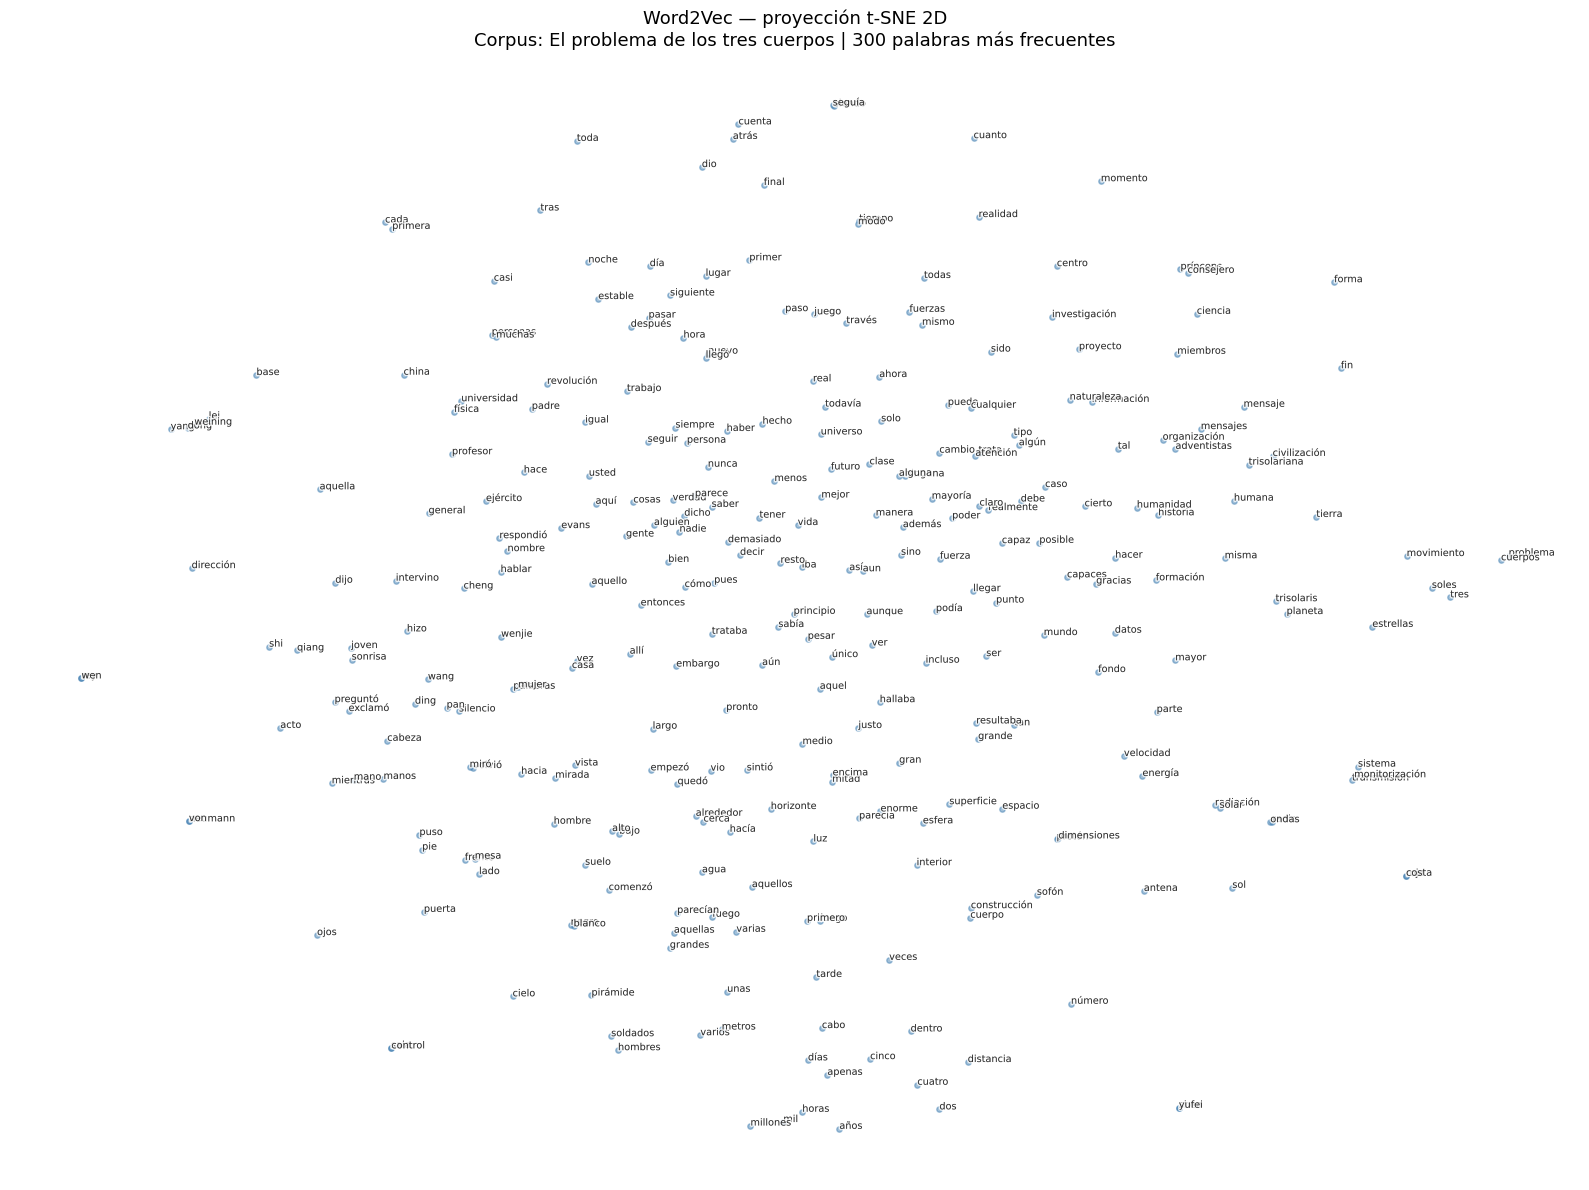

Gráfico guardado como tsne_tres_cuerpos.png


In [100]:
# Visualización
fig, ax = plt.subplots(figsize=(16, 12))

ax.scatter(
    coordenadas[:, 0],
    coordenadas[:, 1],
    s=15,
    alpha=0.5,
    color='steelblue'
)

# Etiquetar cada punto
for i, palabra in enumerate(palabras_top):
    ax.annotate(
        palabra,
        (coordenadas[i, 0], coordenadas[i, 1]),
        fontsize=7,
        alpha=0.8,
        # Borde blanco para legibilidad cuando los puntos se superponen
        path_effects=[
            pe.withStroke(linewidth=2, foreground='white')
        ]
    )

ax.set_title(
    f'Word2Vec — proyección t-SNE 2D\n'
    f'Corpus: El problema de los tres cuerpos | {N_PALABRAS} palabras más frecuentes',
    fontsize=13
)
ax.axis('off')
plt.tight_layout()
plt.savefig('tsne_tres_cuerpos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como tsne_tres_cuerpos.png')

### 7.1 Visualización con palabras clave destacadas

Versión mejorada: resaltar palabras de interés temático con colores por categoría.

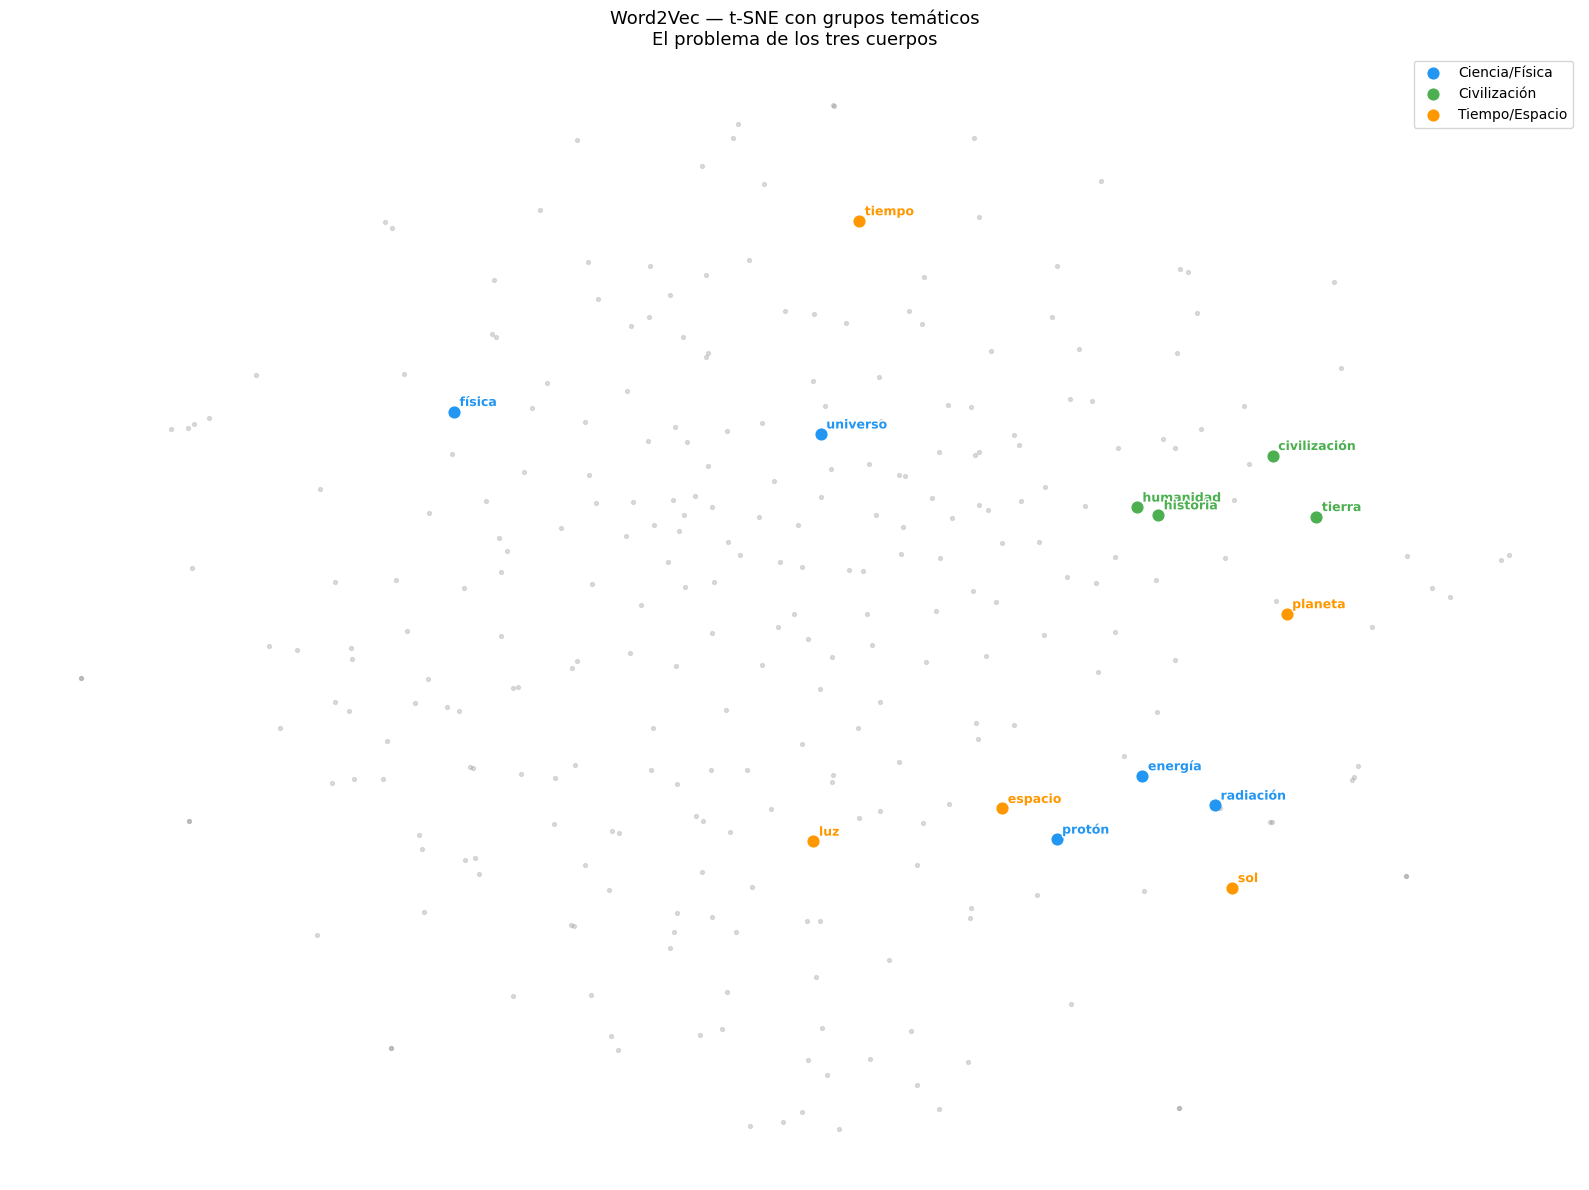

In [101]:
# Definir grupos temáticos para colorear
# AJUSTAR según las palabras que efectivamente estén en tu vocabulario
grupos = {
    'Ciencia/Física' : ['física', 'universo', 'dimensión', 'energía', 'materia',
                        'radiación', 'gravedad', 'partícula', 'protón', 'electrón'],
    'Civilización'   : ['civilización', 'humanidad', 'tierra', 'sociedad',
                        'cultura', 'historia', 'gobierno', 'militar'],
    'Amenaza/Guerra' : ['guerra', 'destrucción', 'ataque', 'invasión',
                        'peligro', 'crisis', 'muerte', 'oscuridad'],
    'Tiempo/Espacio' : ['tiempo', 'espacio', 'cosmos', 'estrella', 'planeta',
                        'galaxia', 'órbita', 'sol', 'luz']
}
colores_grupo = {
    'Ciencia/Física' : '#2196F3',
    'Civilización'   : '#4CAF50',
    'Amenaza/Guerra' : '#F44336',
    'Tiempo/Espacio' : '#FF9800'
}

# Construir mapa palabra → color
color_por_palabra = {}
for grupo, palabras in grupos.items():
    for p in palabras:
        if p in model.wv:
            color_por_palabra[p] = colores_grupo[grupo]

# Graficar
fig, ax = plt.subplots(figsize=(16, 12))

# Fondo: todas las palabras en gris claro
ax.scatter(coordenadas[:, 0], coordenadas[:, 1],
           s=8, alpha=0.25, color='gray')

# Destacar palabras de los grupos
for grupo, palabras in grupos.items():
    for palabra in palabras:
        if palabra in palabras_top:
            idx = palabras_top.index(palabra)
            ax.scatter(
                coordenadas[idx, 0], coordenadas[idx, 1],
                s=60, color=colores_grupo[grupo],
                zorder=3, label=grupo if palabra == palabras[0] else ''
            )
            ax.annotate(
                palabra,
                (coordenadas[idx, 0], coordenadas[idx, 1]),
                fontsize=9, fontweight='bold',
                color=colores_grupo[grupo],
                xytext=(4, 4), textcoords='offset points',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')]
            )

# Leyenda sin duplicados
handles, labels = ax.get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if l not in seen and not seen.add(l)]
ax.legend(*zip(*unique), loc='upper right', fontsize=10)

ax.set_title(
    'Word2Vec — t-SNE con grupos temáticos\n'
    'El problema de los tres cuerpos',
    fontsize=13
)
ax.axis('off')
plt.tight_layout()
plt.savefig('tsne_grupos_tematicos.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis e interpretación

### Observaciones sobre la proyección t-SNE

El gráfico t-SNE no aplica clustering formal — proyecta los vectores a 2D preservando vecindades locales. Las agrupaciones que se observan son aproximaciones visuales, no grupos matemáticamente definidos.

- **`civilización` y `tierra` muy próximas (izquierda):** son las dos palabras de Civilización con mayor frecuencia y aparecen consistentemente en los mismos contextos narrativos de la novela.
- **`humanidad` e `historia` juntas (centro-inferior):** sugiere que en el corpus ambas palabras se enmarcan en reflexiones similares sobre el destino colectivo.
- **`radiación`, `energía`, `protón` forman un pequeño grupo (centro-izquierda):** los términos de Ciencia/Física más concretos se agrupan bien, indicando que el modelo captó un contexto técnico compartido.
- **`física` aparece aislada (inferior-derecha):** su contexto en la novela es más ligado a personajes (Shen Yufei, Yang Dong) que a los fenómenos físicos concretos, lo que la aleja del cluster técnico.
- **`tiempo` y `sol` aparecen aislados:** palabras de muy alta frecuencia y uso variado tienden a dispersarse en t-SNE porque sus vectores promedian demasiados contextos distintos.
- **Grupo Amenaza/Guerra ausente:** ninguna de las palabras de ese grupo (`guerra`, `destrucción`, `invasión`, `crisis`) quedó entre las 300 más frecuentes, lo que sugiere que la novela trata esos temas de forma indirecta, a través de vocabulario abstracto (`destino`, `supervivencia`, `raza`).

### Similitudes más interesantes

- `most_similar('civilización')` devuelve `trisolariana` como vecino más cercano (0.77) — el resultado más semánticamente limpio del modelo. Refleja que ambas palabras aparecen sistemáticamente en los mismos contextos: la amenaza, la supervivencia y el contacto entre civilizaciones son el eje de la novela.
- `most_similar('física')` devuelve `japonesa` como palabra más similar (0.76), lo que no es una relación semántica general sino un artefacto del corpus: Shen Yufei, la física de nacionalidad japonesa, concentra casi todas las apariciones de ambas palabras en contextos adyacentes.
- `most_similar('tierra')` incluye `sondas`, `lanzadas`, `centauro` — el modelo captura el contexto de conflicto interplanetario más que el concepto geográfico del planeta.
- `most_similar('universo')` devuelve `abstracta`, `interminable`, `vasto` — el universo aparece siempre en contextos contemplativos y filosóficos, no técnicos.
- `most_similar('tiempo')` tiene como vecino principal `posibilidad`, seguido de `nave` — "tiempo" aparece predominantemente en contextos de planificación táctica y toma de decisiones, no como concepto filosófico o temporal abstracto.

### Limitaciones observadas

- **Corpus pequeño (~60k tokens):** los scores de similitud coseno raramente superan 0.8, señal de embeddings ruidosos. Con un corpus de este tamaño Word2Vec no logra separar bien polisemia ni capturar relaciones analógicas robustas.
- **Artefactos de tokenización:** si el gráfico t-SNE muestra tokens como `historiaidad`, son producto de ligaduras tipográficas del epub no limpiadas. Indica que el preprocesamiento podría beneficiarse de un paso de normalización de caracteres especiales.
- **Palabras de alta frecuencia y contexto difuso:** términos como `tiempo`, `sol` o `física` aparecen en contextos tan variados que sus embeddings promedian señales contradictorias, reduciéndoles la calidad semántica.

### Conclusiones

Los embeddings entrenados sobre *El problema de los tres cuerpos* capturan correctamente la estructura temática central del libro: la relación civilización humana–civilización trisolariana es la asociación más fuerte del modelo (0.77). El cluster técnico de términos físicos (radiación, energía, protón) también emerge de forma coherente. Sin embargo, las limitaciones del tamaño del corpus son evidentes — varios vecinos semánticos responden a co-ocurrencias locales de personajes (física↔japonesa) antes que a relaciones conceptuales. Para un corpus de esta escala, los embeddings son útiles como herramienta exploratoria pero no generalizarían bien fuera del dominio de la novela.